In [42]:
"""
2026 Grad Colloquium 
=====================================================
Description: This notebook analyses the number of no-risk days per region for solar lulls. 

Version History: 18/06/2026 S.A wrote script 

Notes:
"""


'\n2026 Grad Colloquium \n=====================================================\nDescription: This notebook analyses the number of no-risk days per region for solar lulls. \n\nVersion History: 18/06/2026 S.A wrote script \n\nNotes:\n'

In [7]:
from pathlib import Path
import xarray as xr         # NetCDF & multi-dimensional data
import pandas as pd          # tabular/CSV data
import numpy as np           # numerical operations
import matplotlib.pyplot as plt  # plotting
from glob import glob        #global path directory

In [8]:
risk = pd.read_csv("/scratch/nf33/ad1803/GC26_Solar_Lull/Work/Data/Lulls/event_risk_by_duration_all_days.csv")
risk

,Unnamed: 0,time,Q5,T2,Q8,V5,V1,T3,S6,V2,...,N4,N3,GPER,ACTE,GBRI,GDAR,GHOB,GMEL,GADE,GSYD
0,0,2015-08-01,none,none,none,low,low,none,none,low,...,none,none,none,none,none,none,none,low,low,none
1,1,2015-08-02,none,low,none,none,none,none,none,none,...,none,none,none,low,none,none,none,none,none,none
2,2,2015-08-03,none,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3,3,2015-08-04,none,low,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
4,4,2015-08-05,none,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3801,3801,2025-12-27,high,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3802,3802,2025-12-28,high,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3803,3803,2025-12-29,high,none,none,none,none,none,none,none,...,none,none,none,none,none,none,none,none,none,none
3804,3804,2025-12-30,high,low,none,none,none,low,none,none,...,none,none,none,none,none,none,none,none,none,none


In [9]:
regions = risk.columns.drop('time')

none_days = {}

for region in regions: 
    none_days[region]=np.count_nonzero(risk[region]=='none')

none_days = pd.DataFrame({
    'region': none_days.keys(),
    'none_days': none_days.values()
})
none_days 

#none_days = pd.Series(no_days)
#print(none_days.sort_values(ascending=False))

,region,none_days
0,Unnamed: 0,0
1,Q5,3437
2,T2,2487
3,Q8,3281
4,V5,2775
5,V1,2816
6,T3,3024
7,S6,3491
8,V2,3311
9,Q9,3327


In [10]:
import geopandas as gpd 
gdf = gpd.read_file("/scratch/nf33/ad1803/GC26_Solar_Lull/Training/Data/REZs/REZ_Map.shp")
gdf

,name,source_fil,geometry
0,Q1,shapefile_1,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -..."
1,Q2,shapefile_1,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -..."
2,Q3,shapefile_1,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1..."
3,Q4,shapefile_1,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -..."
4,Q5,shapefile_1,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2..."
5,Q6,shapefile_1,"POLYGON Z ((149.9586 -24.15382 0, 149.93313 -2..."
6,Q7,shapefile_1,"POLYGON Z ((152.2709 -25.06574 0, 152.277 -25...."
7,Q8,shapefile_1,"POLYGON Z ((150.85196 -26.29194 0, 151.08218 -..."
8,Q9,shapefile_1,"POLYGON Z ((149.13813 -23.31492 0, 149.33179 -..."
9,N1,shapefile_1,"POLYGON Z ((149.63862 -28.78058 0, 149.71236 -..."


In [11]:
merged = gdf.merge(none_days, left_on='name', right_on='region', how='left')

In [14]:
merged

,name,source_fil,geometry,region,none_days
0,Q1,shapefile_1,"POLYGON Z ((146.13492 -17.65256 0, 146.09724 -...",NaN,NaN
1,Q2,shapefile_1,"POLYGON Z ((143.72015 -16.97938 0, 143.87955 -...",Q2,3445.0
2,Q3,shapefile_1,"POLYGON Z ((146.27782 -18.7192 0, 146.28263 -1...",Q3,3109.0
3,Q4,shapefile_1,"POLYGON Z ((147.64366 -19.94015 0, 147.68341 -...",Q4,3294.0
4,Q5,shapefile_1,"POLYGON Z ((145.82086 -23.84279 0, 145.7004 -2...",Q5,3437.0
5,Q6,shapefile_1,"POLYGON Z ((149.9586 -24.15382 0, 149.93313 -2...",Q6,3268.0
6,Q7,shapefile_1,"POLYGON Z ((152.2709 -25.06574 0, 152.277 -25....",Q7,3121.0
7,Q8,shapefile_1,"POLYGON Z ((150.85196 -26.29194 0, 151.08218 -...",Q8,3281.0
8,Q9,shapefile_1,"POLYGON Z ((149.13813 -23.31492 0, 149.33179 -...",Q9,3327.0
9,N1,shapefile_1,"POLYGON Z ((149.63862 -28.78058 0, 149.71236 -...",N1,3329.0


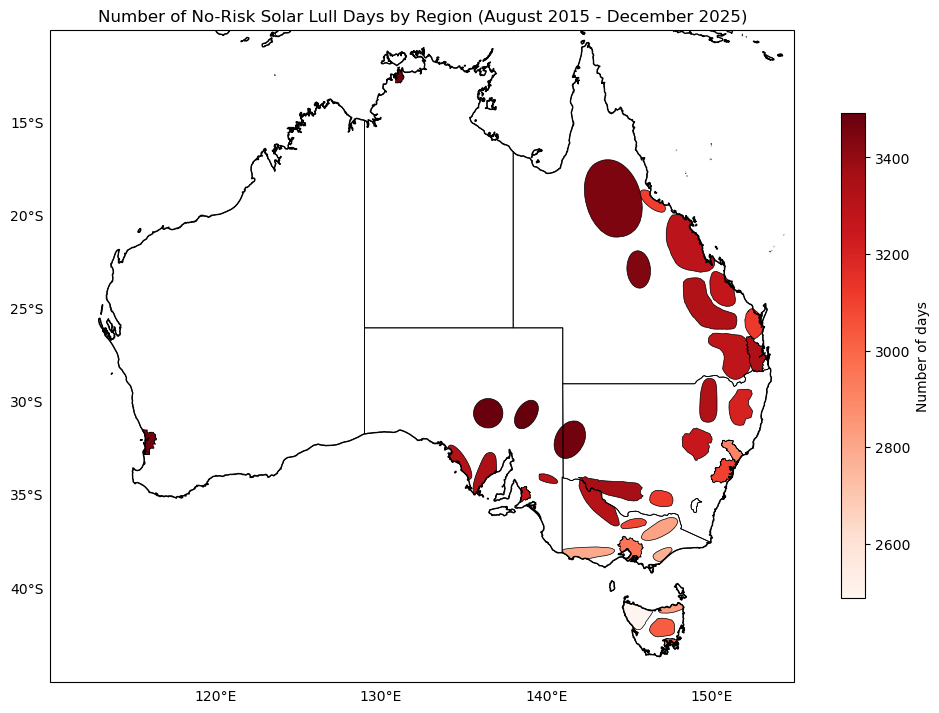

In [47]:
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

fig = plt.figure(figsize=(10, 10))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([110, 155, -45, -10], crs=ccrs.PlateCarree())

merged.plot(column='none_days', cmap='Reds', linewidth=0.5, edgecolor='black', legend=False, ax=ax, transform=ccrs.PlateCarree())

ax.coastlines(resolution="10m", linewidth=1.0)
ax.add_feature(cfeature.BORDERS, linewidth=0.8)
ax.add_feature(cfeature.STATES, linewidth=0.6)

gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False
gl.right_labels = False
gl.xlines = False
gl.ylines = False

sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=merged['none_days'].min(), vmax=merged['none_days'].max()))
sm._A = []
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('Number of days')

ax.set_title('Number of No-Risk Solar Lull Days by Region (August 2015 - December 2025)')
plt.tight_layout()
plt.show()